In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, classification_report, roc_curve
import optuna

RANDOM_STATE = 42

In [58]:
def manual_confusion_matrix(y_true, y_pred):
    classes = np.unique(np.concatenate([y_true, y_pred]))
    cm = np.zeros((len(classes), len(classes)), dtype=int)
    idx = {c: i for i, c in enumerate(classes)}
    for t, p in zip(y_true, y_pred):
        cm[idx[t], idx[p]] += 1
    return cm, classes

def manual_metrics(y_true, y_pred, y_proba, average='weighted'):
    cm, classes = manual_confusion_matrix(y_true, y_pred)
    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    
    acc = np.sum(tp) / np.sum(cm)
    
    prec = np.where((tp + fp) > 0, tp / (tp + fp), 0.0)
    rec  = np.where((tp + fn) > 0, tp / (tp + fn), 0.0)
    f1   = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec), 0.0)
    
    roc_auc_per_class = []
    for i, cls in enumerate(classes):
        pos_proba = y_proba[y_true == cls, i]
        neg_proba = y_proba[y_true != cls, i]
        
        if len(pos_proba) == 0 or len(neg_proba) == 0:
            roc_auc_per_class.append(0.5)
            continue
            
        more = np.sum(pos_proba[:, np.newaxis] > neg_proba)
        equal = np.sum(pos_proba[:, np.newaxis] == neg_proba)
        
        auc = (more + 0.5 * equal) / (len(pos_proba) * len(neg_proba))
        roc_auc_per_class.append(auc)
        
    roc_auc_per_class = np.array(roc_auc_per_class)
    
    if average == 'weighted':
        sup = tp + fn
        w = sup / sup.sum()
        return np.sum(prec * w), np.sum(rec * w), np.sum(f1 * w), acc, np.sum(roc_auc_per_class * w)
    elif average == 'macro':
        return prec.mean(), rec.mean(), f1.mean(), acc, roc_auc_per_class.mean()
        
    return prec, rec, f1, acc, roc_auc_per_class


In [27]:
def plot_beautiful_confusion_matrix(y_true, y_pred, title="Матрица смежности"):
    cm = confusion_matrix(y_true, y_pred)
    classes = np.unique(y_true)
    
    sns.set_theme(style="whitegrid", font_scale=1.1)
    plt.figure(figsize=(8, 6), dpi=100)
    
    cm_ratio = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    labels = (np.array([f"{v}\n({p:.1%})" for v, p in zip(cm.flatten(), cm_ratio.flatten())])).reshape(cm.shape)
    
    ax = sns.heatmap(cm, annot=labels, fmt="", cmap="crest", cbar=True,
                     xticklabels=classes, yticklabels=classes,
                     linewidths=1.5, linecolor="white", square=True)
    
    plt.title(title, fontsize=16, pad=20, weight='bold', color='#2c3e50')
    plt.xlabel('Предсказанные классы', fontsize=12, labelpad=10, weight='semibold', color='#34495e')
    plt.ylabel('Истинные классы', fontsize=12, labelpad=10, weight='semibold', color='#34495e')
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()

In [28]:
data = pd.read_csv("../csv/cl_finished.csv", sep = ';')

X = data.drop(columns=['Diabetes_012'])
y = data['Diabetes_012']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y)


In [29]:
y.value_counts()

Diabetes_012
0    190055
2     35097
1      4629
Name: count, dtype: int64

**Классификация - мультиклассовая**

([<matplotlib.patches.Wedge at 0x1ce002279d0>,
 [Text(-0.941699975714862, 0.5685078326097439, ''),
  Text(0.903858888437878, -0.6269283131202832, ''),
  Text(1.0977977786141369, -0.06957037638152071, '')])

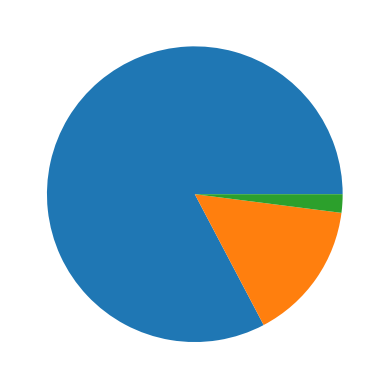

In [30]:
plt.pie(y.value_counts())

Для данной выборки будем использовать **oversampling**

In [31]:
sm = SMOTE(random_state = RANDOM_STATE)

X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

In [32]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [33]:
X_train_res = X_train_resampled.sample(n=10000, random_state=RANDOM_STATE)
y_train_res = y_train_resampled[X_train_res.index]

**Логистическая регрессия**

In [34]:
def objective_logReg(trial):

    penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet'])
    tol = trial.suggest_float('tol', 1e-5, 1e2, log = True)
    fit_intercept = trial.suggest_categorical('fit_intercept', [True, False])
    max_iter = trial.suggest_int('max_iter', 1e2, 5e3, log = True)
    C = trial.suggest_float('C', 1e-3, 1e2, log = True)

    l1_ratio = None
    if penalty == 'elasticnet':
        l1_ratio = trial.suggest_float('l1_ratio', 0, 1)
    
    model = LogisticRegression(penalty = penalty, tol = tol, fit_intercept = fit_intercept, C = C,
                                max_iter = max_iter, solver = 'saga', l1_ratio = l1_ratio, random_state = RANDOM_STATE)

    score = cross_val_score(model, X_train_res, y_train_res, cv = cv, scoring = "f1_weighted")

    return score.mean()

In [35]:
study_logReg = optuna.create_study(direction = 'maximize')
study_logReg.optimize(objective_logReg, n_trials = 10)

best_model_logReg = LogisticRegression(**study_logReg.best_params, solver = 'saga', random_state = RANDOM_STATE)

best_model_logReg.fit(X_train_resampled, y_train_resampled)
best_pred_logReg = best_model_logReg.predict(X_test)
best_pred_logreg_proba = best_model_logReg.predict_proba(X_test)


[I 2026-05-16 01:16:18,262] A new study created in memory with name: no-name-c8965ab4-f91e-438c-a776-05d46d29a281
[I 2026-05-16 01:16:20,081] Trial 0 finished with value: 0.5327407987853282 and parameters: {'penalty': 'elasticnet', 'tol': 0.006068426030561596, 'fit_intercept': True, 'max_iter': 933, 'C': 38.10537689117854, 'l1_ratio': 0.5861083223964961}. Best is trial 0 with value: 0.5327407987853282.
C:\Users\zuzin\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\zuzin\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\zuzin\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\

Logistic Regression
sklearn metrics
----------------------------
f1_score: 0.6827940662002271
Accuracy: 0.6155944005222311
Precision: 0.8041274577256871
Recall: 0.6155944005222311


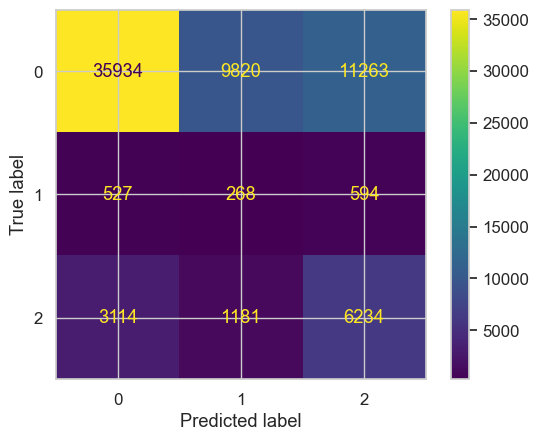

Roc-auc: 0.7207107257021345

manual metrics
----------------------------
f1_score: 0.682794066200227
Accuracy: 0.6155944005222311
Precision: 0.804127457725687
Recall: 0.615594400522231
Roc-auc: 0.7207107257021346


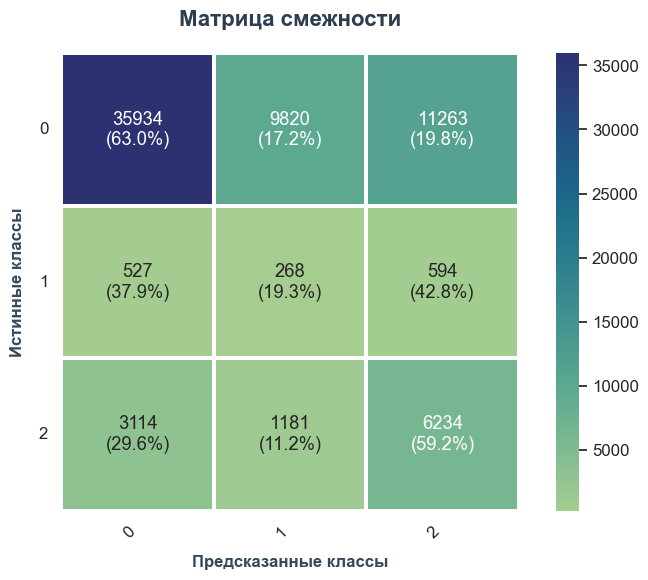

In [59]:
print("Logistic Regression")
print("sklearn metrics")
print("----------------------------")
print(f"f1_score: {f1_score(y_test, best_pred_logReg, average = "weighted")}")
print(f"Accuracy: {accuracy_score(y_test, best_pred_logReg)}")
print(f"Precision: {precision_score(y_test, best_pred_logReg, average = "weighted")}")
print(f"Recall: {recall_score(y_test, best_pred_logReg, average = "weighted")}")
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, best_pred_logReg), display_labels=np.unique(y_test))
disp.plot(cmap='viridis')
plt.show()

roc_auc = roc_auc_score(y_test, best_pred_logreg_proba, average="weighted", multi_class="ovr")
print(f"Roc-auc: {roc_auc}")

man_logReg_prec, man_logReg_rec, man_logReg_f1, man_logReg_acc, man_logReg_roc_auc = manual_metrics(y_test, best_pred_logReg, y_proba = best_pred_logreg_proba)

print("\nmanual metrics")
print("----------------------------")
print(f"f1_score: {man_logReg_f1}")
print(f"Accuracy: {man_logReg_acc}")
print(f"Precision: {man_logReg_prec}")
print(f"Recall: {man_logReg_rec}")
print(f"Roc-auc: {man_logReg_roc_auc}")
plot_beautiful_confusion_matrix(y_test, best_pred_logReg)


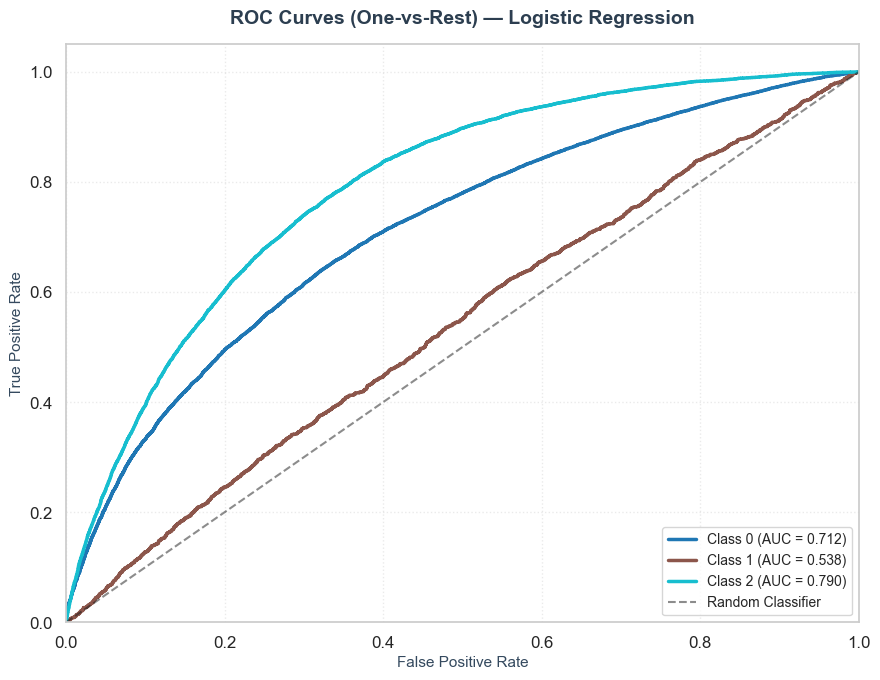

Weighted ROC-AUC : 0.7207


In [65]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(9, 7), dpi=100)
classes = np.unique(y_test)
colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))

for i, cls in enumerate(classes):
    y_binary = (y_test == cls).astype(int)
    y_score = best_pred_logreg_proba[:, i]
    
    fpr, tpr, _ = roc_curve(y_binary, y_score)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color=colors[i], linewidth=2.5,
             label=f'Class {cls} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=11, color='#34495e')
plt.ylabel('True Positive Rate', fontsize=11, color='#34495e')
plt.title('ROC Curves (One-vs-Rest) — Logistic Regression', 
          fontsize=14, weight='bold', pad=15, color='#2c3e50')
plt.legend(loc='lower right', fontsize=10, frameon=True)
plt.grid(True, linestyle=':', alpha=0.4)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

weighted_auc = roc_auc_score(y_test, best_pred_logreg_proba, 
                             average='weighted', multi_class='ovr')
print(f"Weighted ROC-AUC : {weighted_auc:.4f}")

**KNN**

In [ ]:
def objective_KNN(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 3, 15)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    leaf_size = trial.suggest_int('leaf_size', 10, 50)
    p = trial.suggest_int('p', 1, 2)

    model = KNeighborsClassifier(n_neighbors = n_neighbors, weights = weights, leaf_size = leaf_size, p = p, n_jobs=-1)

    score = cross_val_score(model, X_train_res, y_train_res, cv = cv, scoring='f1_weighted')

    return score.mean()

In [38]:
study_KNN = optuna.create_study(direction = "maximize")
study_KNN.optimize(objective_KNN, n_trials = 10, show_progress_bar=True)

best_model_KNN = KNeighborsClassifier(**study_KNN.best_params)

best_model_KNN.fit(X_train_resampled, y_train_resampled)

best_pred_KNN = best_model_KNN.predict(X_test)
best_pred_KNN_proba = best_model_KNN.predict_proba(X_test)

[I 2026-05-16 01:23:29,334] A new study created in memory with name: no-name-f924df54-4d91-4df5-ae09-d3b02ca80e4c


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-05-16 01:23:30,305] Trial 0 finished with value: 0.5830081278132051 and parameters: {'n_neighbors': 14, 'weights': 'distance', 'leaf_size': 31, 'p': 1}. Best is trial 0 with value: 0.5830081278132051.
[I 2026-05-16 01:23:31,501] Trial 1 finished with value: 0.5818926146638835 and parameters: {'n_neighbors': 4, 'weights': 'distance', 'leaf_size': 14, 'p': 2}. Best is trial 0 with value: 0.5830081278132051.
[I 2026-05-16 01:23:32,696] Trial 2 finished with value: 0.5688605431526264 and parameters: {'n_neighbors': 11, 'weights': 'distance', 'leaf_size': 25, 'p': 2}. Best is trial 0 with value: 0.5830081278132051.
[I 2026-05-16 01:23:33,852] Trial 3 finished with value: 0.5723641648694416 and parameters: {'n_neighbors': 7, 'weights': 'distance', 'leaf_size': 10, 'p': 2}. Best is trial 0 with value: 0.5830081278132051.
[I 2026-05-16 01:23:35,017] Trial 4 finished with value: 0.5217006403582898 and parameters: {'n_neighbors': 13, 'weights': 'uniform', 'leaf_size': 19, 'p': 2}. Best i

KNN
sklearn metrics
----------------------------
f1_score: 0.6531189406708822
Accuracy: 0.586871690723145
Precision: 0.7753270585133604
Recall: 0.586871690723145


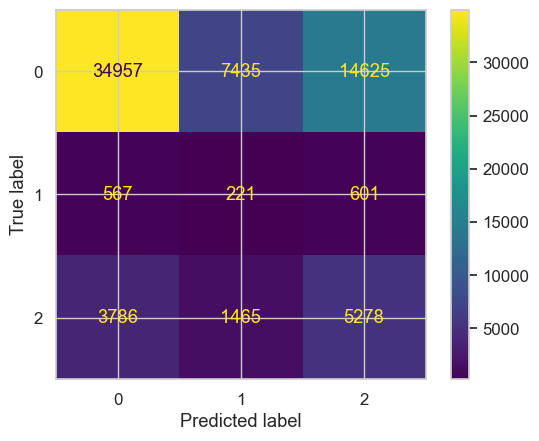

Roc-auc: 0.6553799497995683

manual metrics
----------------------------
f1_score: 0.6531189406708823
Accuracy: 0.586871690723145
Precision: 0.7753270585133604
Recall: 0.5868716907231449
Roc-auc: 0.6553799497995684


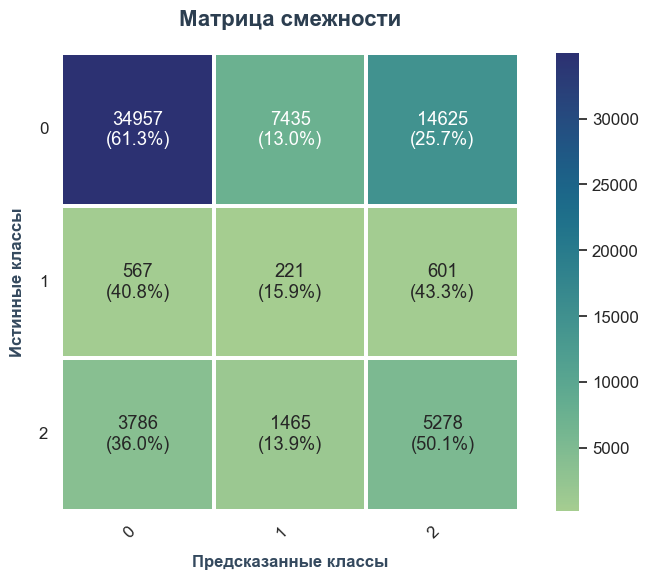

In [61]:
print("KNN")
print("sklearn metrics")
print("----------------------------")
print(f"f1_score: {f1_score(y_test, best_pred_KNN, average = "weighted")}")
print(f"Accuracy: {accuracy_score(y_test, best_pred_KNN)}")
print(f"Precision: {precision_score(y_test, best_pred_KNN, average = "weighted")}")
print(f"Recall: {recall_score(y_test, best_pred_KNN, average = "weighted")}")
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, best_pred_KNN), display_labels=np.unique(y_test))
disp.plot(cmap='viridis')
plt.show()

roc_auc = roc_auc_score(y_test, best_pred_KNN_proba, average="weighted", multi_class="ovr")
print(f"Roc-auc: {roc_auc}")

man_KNN_prec, man_KNN_rec, man_KNN_f1, man_KNN_acc, man_KNN_roc_auc = manual_metrics(y_test, best_pred_KNN, best_pred_KNN_proba)

print("\nmanual metrics")
print("----------------------------")
print(f"f1_score: {man_KNN_f1}")
print(f"Accuracy: {man_KNN_acc}")
print(f"Precision: {man_KNN_prec}")
print(f"Recall: {man_KNN_rec}")
print(f"Roc-auc: {man_KNN_roc_auc}")

plot_beautiful_confusion_matrix(y_test, best_pred_KNN)


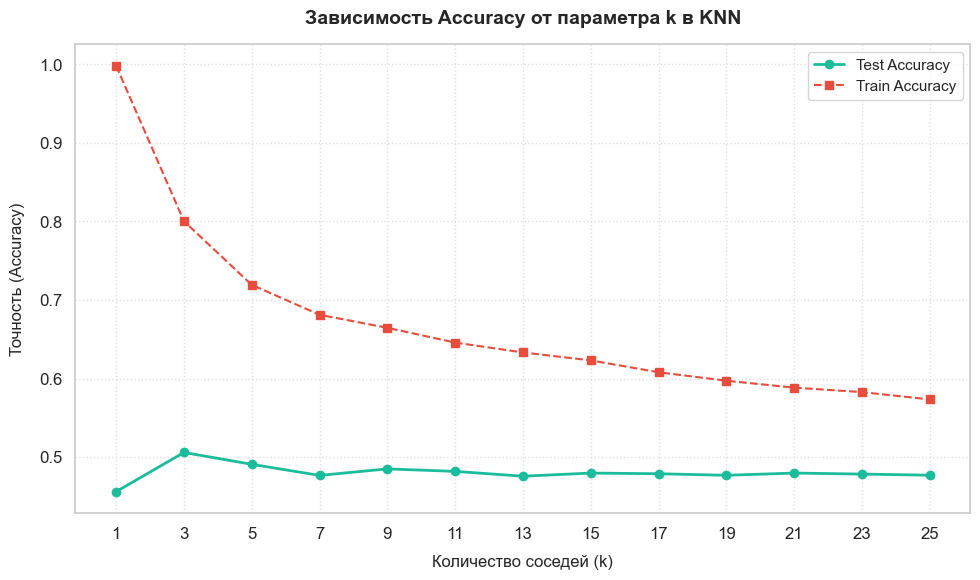

In [64]:
k_values = list(range(1, 26, 2))

train_accuracy = []
test_accuracy = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train_res, y_train_res)
    
    y_train_pred = knn.predict(X_train_res)
    train_accuracy.append(accuracy_score(y_train_res, y_train_pred))
    
    y_test_pred = knn.predict(X_test)
    test_accuracy.append(accuracy_score(y_test, y_test_pred))

plt.figure(figsize=(10, 6), dpi=100)

plt.plot(k_values, test_accuracy, marker='o', linestyle='-', linewidth=2, color='#1abc9c', label='Test Accuracy')

plt.plot(k_values, train_accuracy, marker='s', linestyle='--', linewidth=1.5, color='#e74c3c', label='Train Accuracy')

plt.title('Зависимость Accuracy от параметра k в KNN', fontsize=14, weight='bold', pad=15)
plt.xlabel('Количество соседей (k)', fontsize=12, labelpad=10)
plt.ylabel('Точность (Accuracy)', fontsize=12, labelpad=10)
plt.xticks(k_values)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='best')

plt.tight_layout()
plt.show()

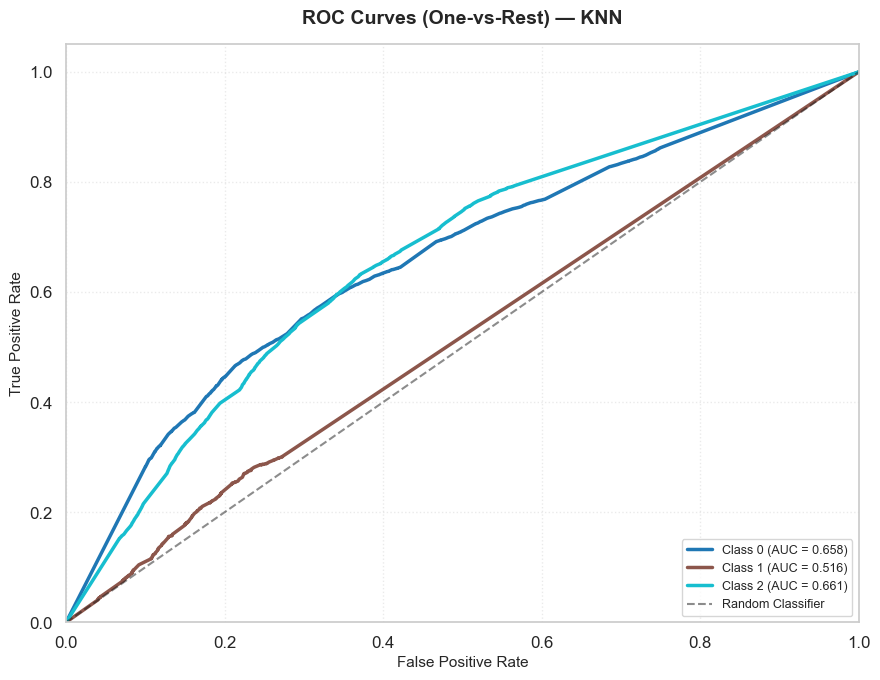

Weighted ROC-AUC: 0.6554


In [66]:
plt.figure(figsize=(9, 7), dpi=100)
classes = np.unique(y_test)
colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))

for i, cls in enumerate(classes):
    y_binary = (y_test == cls).astype(int)
    y_score = best_pred_KNN_proba[:, i]
    
    fpr, tpr, _ = roc_curve(y_binary, y_score)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color=colors[i], linewidth=2.5,
             label=f'Class {cls} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curves (One-vs-Rest) — KNN', 
          fontsize=14, weight='bold', pad=15)
plt.legend(loc='lower right', fontsize=9, frameon=True)
plt.grid(True, linestyle=':', alpha=0.4)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

weighted_auc = roc_auc_score(y_test, best_pred_KNN_proba, 
                             average='weighted', multi_class='ovr')
print(f"Weighted ROC-AUC: {weighted_auc:.4f}")

**Naive Bayes**

In [40]:
def objective_naive_bayes(trial):
    var_smoothing = trial.suggest_float('var_smoothing', 1e-10, 1, log = True)

    model = GaussianNB(var_smoothing = var_smoothing)

    score = cross_val_score(model, X_train_resampled, y_train_resampled, cv = 5, scoring = 'f1_weighted').mean()

    return score

In [41]:
study_GaussianNB = optuna.create_study(direction = 'maximize')
study_GaussianNB.optimize(objective_naive_bayes, n_trials = 20)

best_model_GaussianNB = GaussianNB(**study_GaussianNB.best_params)

best_model_GaussianNB.fit(X_train_resampled, y_train_resampled)

best_pred_GaussianNB = best_model_GaussianNB.predict(X_test)
best_pred_GaussianNB_proba = best_model_GaussianNB.predict_proba(X_test)

[I 2026-05-16 01:36:21,585] A new study created in memory with name: no-name-4cf5b8de-a614-4ea2-af00-4940d5b81920
[I 2026-05-16 01:36:22,493] Trial 0 finished with value: 0.49484477270786364 and parameters: {'var_smoothing': 0.00012801042248734832}. Best is trial 0 with value: 0.49484477270786364.
[I 2026-05-16 01:36:23,393] Trial 1 finished with value: 0.4426397811585888 and parameters: {'var_smoothing': 1.6419280689688373e-07}. Best is trial 0 with value: 0.49484477270786364.
[I 2026-05-16 01:36:24,296] Trial 2 finished with value: 0.5087852325618512 and parameters: {'var_smoothing': 0.0002799501723015159}. Best is trial 2 with value: 0.5087852325618512.
[I 2026-05-16 01:36:25,180] Trial 3 finished with value: 0.49380088776114633 and parameters: {'var_smoothing': 0.0017947365234419334}. Best is trial 2 with value: 0.5087852325618512.
[I 2026-05-16 01:36:26,069] Trial 4 finished with value: 0.47700853620076644 and parameters: {'var_smoothing': 5.523644782863406e-05}. Best is trial 2 w

GaussianNB
sklearn metrics
----------------------------
f1_score: 0.6262477500700081
Accuracy: 0.5344599985493581
Precision: 0.815235069536229
Recall: 0.5344599985493581


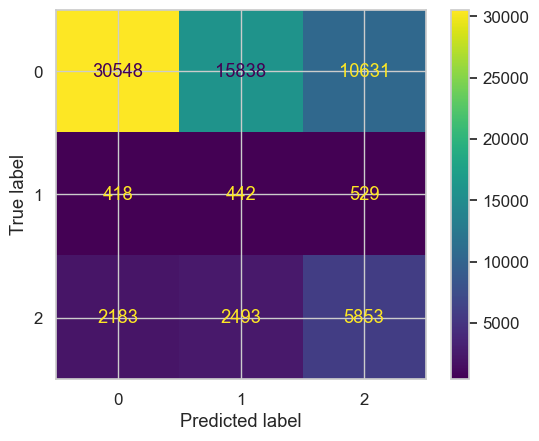

Roc-auc: 0.7309576236379626

manual metrics
----------------------------
f1_score: 0.626247750070008
Accuracy: 0.5344599985493581
Precision: 0.815235069536229
Recall: 0.5344599985493581
Roc-auc: 0.7309576236379625


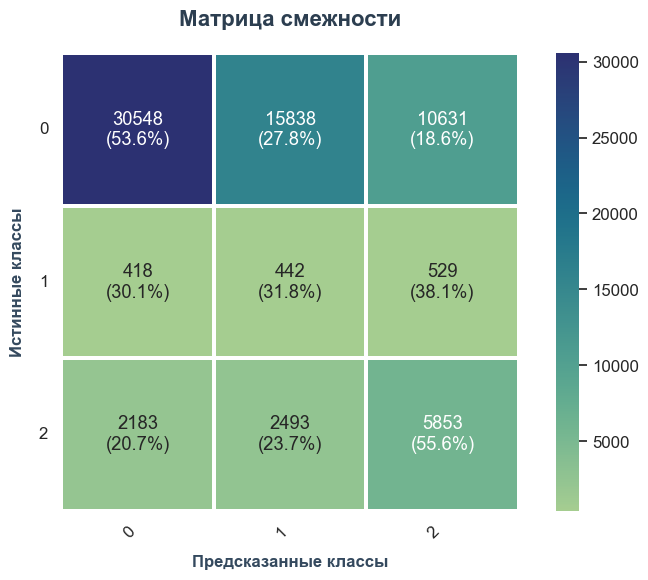

In [62]:
print("GaussianNB")
print("sklearn metrics")
print("----------------------------")
print(f"f1_score: {f1_score(y_test, best_pred_GaussianNB, average = "weighted")}")
print(f"Accuracy: {accuracy_score(y_test, best_pred_GaussianNB)}")
print(f"Precision: {precision_score(y_test, best_pred_GaussianNB, average = "weighted")}")
print(f"Recall: {recall_score(y_test, best_pred_GaussianNB, average = "weighted")}")
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, best_pred_GaussianNB), display_labels=np.unique(y_test))
disp.plot(cmap='viridis')
plt.show()

roc_auc = roc_auc_score(y_test, best_pred_GaussianNB_proba, average="weighted", multi_class="ovr")
print(f"Roc-auc: {roc_auc}")

man_GaussianNB_prec, man_GaussianNB_rec, man_GaussianNB_f1, man_GaussianNB_acc, man_GaussianNB_roc_auc = manual_metrics(y_test, best_pred_GaussianNB, best_pred_GaussianNB_proba)

print("\nmanual metrics")
print("----------------------------")
print(f"f1_score: {man_GaussianNB_f1}")
print(f"Accuracy: {man_GaussianNB_acc}")
print(f"Precision: {man_GaussianNB_prec}")
print(f"Recall: {man_GaussianNB_rec}")
print(f"Roc-auc: {man_GaussianNB_roc_auc}")

plot_beautiful_confusion_matrix(y_test, best_pred_GaussianNB)

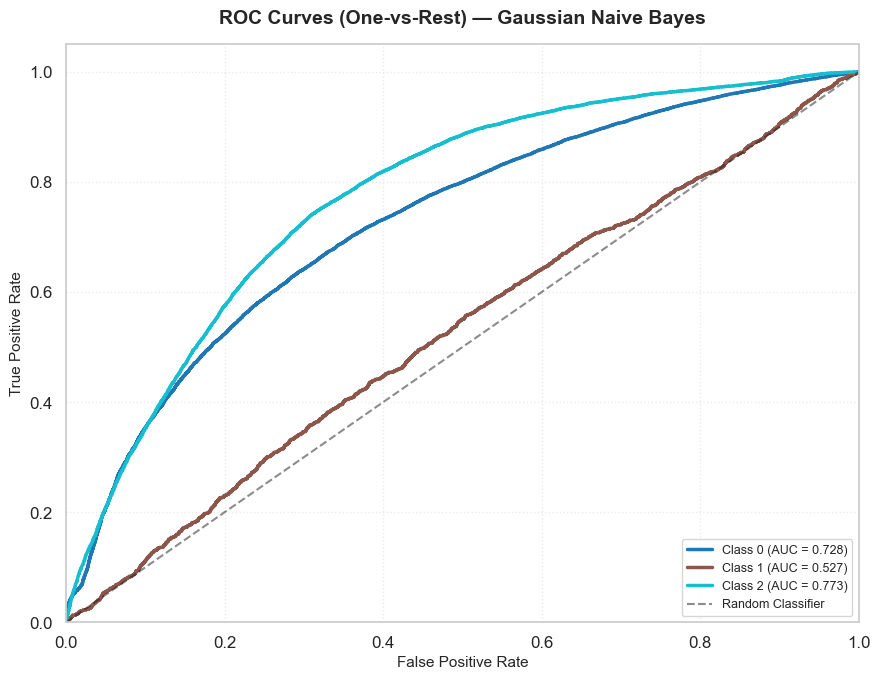

Weighted ROC-AUC (OVR): 0.7310


In [67]:
plt.figure(figsize=(9, 7), dpi=100)
classes = np.unique(y_test)
colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))

for i, cls in enumerate(classes):
    y_binary = (y_test == cls).astype(int)
    y_score = best_pred_GaussianNB_proba[:, i]
    
    fpr, tpr, _ = roc_curve(y_binary, y_score)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color=colors[i], linewidth=2.5,
             label=f'Class {cls} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curves (One-vs-Rest) — Gaussian Naive Bayes', 
          fontsize=14, weight='bold', pad=15)
plt.legend(loc='lower right', fontsize=9, frameon=True)
plt.grid(True, linestyle=':', alpha=0.4)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

weighted_auc = roc_auc_score(y_test, best_pred_GaussianNB_proba, 
                             average='weighted', multi_class='ovr')
print(f"Weighted ROC-AUC (OVR): {weighted_auc:.4f}")

**SVM**

In [69]:
X_train_sub = X_train_resampled.sample(n=5000, random_state=RANDOM_STATE)
y_train_sub = y_train_resampled[X_train_sub.index]

def objective_svc(trial):
    C = trial.suggest_float('C', 1e-2, 1e3, log = True)
    kernel = trial.suggest_categorical('kernel', ['linear', 'poly', 'rbf', 'sigmoid'])

    params = {'C': C, 'kernel': kernel}
    if kernel in ['rbf', 'poly', 'sigmoid']:
        params['gamma'] = trial.suggest_float('gamma', 1e-4, 10, log = True)

    if kernel == 'poly':
        params['degree'] = trial.suggest_int('degree', 2, 5)

    model = SVC(**params)

    score = cross_val_score(model, X_train_sub, y_train_sub, cv = 5, scoring = 'f1_weighted').mean()

    return score

In [ ]:
study_svc = optuna.create_study(direction = 'maximize')
study_svc.optimize(objective_svc, n_trials = 10)

best_model_SVC = SVC(**study_svc.best_params, probability=True)

best_model_SVC.fit(X_train_resampled, y_train_resampled)

best_pred_SVC = best_model_SVC.predict(X_test)
best_pred_SVC_proba = best_model_SVC.predict_proba(X_test)

[I 2026-05-16 00:11:45,083] A new study created in memory with name: no-name-c9fab7af-c2c2-4ab0-8519-da4b8759062d
[I 2026-05-16 00:11:50,975] Trial 0 finished with value: 0.23578029153734015 and parameters: {'C': 5.761173679311382, 'kernel': 'rbf', 'gamma': 7.306047985596768}. Best is trial 0 with value: 0.23578029153734015.
[I 2026-05-16 00:11:53,374] Trial 1 finished with value: 0.1732469108595724 and parameters: {'C': 0.0025858352958755496, 'kernel': 'sigmoid', 'gamma': 0.7745539225170711}. Best is trial 0 with value: 0.23578029153734015.
[I 2026-05-16 00:11:56,872] Trial 2 finished with value: 0.5483075365367054 and parameters: {'C': 46.826983349610224, 'kernel': 'rbf', 'gamma': 0.0003121682061536748}. Best is trial 2 with value: 0.5483075365367054.
[I 2026-05-16 00:11:59,393] Trial 3 finished with value: 0.3392040085493073 and parameters: {'C': 0.051307767518094315, 'kernel': 'poly', 'gamma': 0.0003495046373547462, 'degree': 2}. Best is trial 2 with value: 0.5483075365367054.


In [ ]:
print("SVC")
print("sklearn metrics")
print("----------------------------")
print(f"f1_score: {f1_score(y_test, best_pred_SVC, average = "weighted")}")
print(f"Accuracy: {accuracy_score(y_test, best_pred_SVC)}")
print(f"Precision: {precision_score(y_test, best_pred_SVC, average = "weighted")}")
print(f"Recall: {recall_score(y_test, best_pred_SVC, average = "weighted")}")
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, best_pred_SVC), display_labels=np.unique(y_test))
disp.plot(cmap='viridis')

roc_auc = roc_auc_score(y_test, best_pred_SVC_proba, average="weighted", multi_class="ovr")
print(f"Roc-auc: {roc_auc}")

man_SVC_prec, man_SVC_rec, man_SVC_f1, man_SVC_acc = manual_metrics(y_test, best_pred_SVC)

print("\nmanual metrics")
print("----------------------------")
print(f"f1_score: {man_SVC_f1}")
print(f"Accuracy: {man_SVC_acc}")
print(f"Precision: {man_SVC_prec}")
print(f"Recall: {man_SVC_rec}")

plot_beautiful_confusion_matrix(y_test, best_pred_SVC)

In [ ]:
plt.figure(figsize=(9, 7), dpi=100)
classes = np.unique(y_test)
colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))

for i, cls in enumerate(classes):
    y_binary = (y_test == cls).astype(int)
    
    y_score = best_pred_SVC_proba[:, i]
    
    fpr, tpr, _ = roc_curve(y_binary, y_score)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color=colors[i], linewidth=2.5,
             label=f'Class {cls} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curves (One-vs-Rest) — SVM', 
          fontsize=14, weight='bold', pad=15)
plt.legend(loc='lower right', fontsize=9, frameon=True)
plt.grid(True, linestyle=':', alpha=0.4)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

weighted_auc = roc_auc_score(y_test, best_pred_SVC_proba, average='weighted', multi_class='ovr')
print(f"Weighted ROC-AUC: {weighted_auc:.4f}")

In [48]:
class MyKNN:
    def __init__(self, k=3, metric='euclidean'):
        self.k = k
        self.metric = metric.lower()
        self.X_train = None
        self.y_train = None

    def _calc_dist(self, X1, X2):
        diff = X1 - X2
        if self.metric == 'euclidean':
            return np.sqrt(np.sum(diff**2, axis=1))
        elif self.metric == 'manhattan':
            return np.sum(np.abs(diff), axis=1)
        elif self.metric == 'chebyshev':
            return np.max(np.abs(diff), axis=1)

    def fit(self, X, y):
        self.X_train = np.asarray(X)
        self.y_train = np.asarray(y)
        return self

    def predict(self, X):
        X = np.asarray(X)
        preds = []
        for x in X:
            dists = self._calc_dist(self.X_train, x)
            k_idx = np.argpartition(dists, self.k)[:self.k]
            k_labels = self.y_train[k_idx]
            
            classes, counts = np.unique(k_labels, return_counts=True)
            preds.append(classes[np.argmax(counts)])
        return np.asarray(preds)



In [49]:
my_knn = MyKNN(k=5, metric='euclidean')
my_knn.fit(X_train_res, y_train_res)
my_preds = my_knn.predict(X_test)

Logistic Regression
sklearn metrics
----------------------------
f1_score: 0.5891814274266012
Accuracy: 0.4907521578298397
Precision: 0.7896895264117529
Recall: 0.4907521578298397


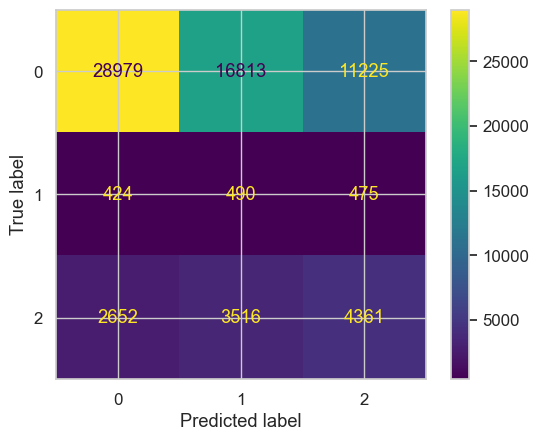

Roc-auc: 0.7207107257021345

manual metrics
----------------------------
f1_score: 0.682794066200227
Accuracy: 0.6155944005222311
Precision: 0.804127457725687
Recall: 0.615594400522231


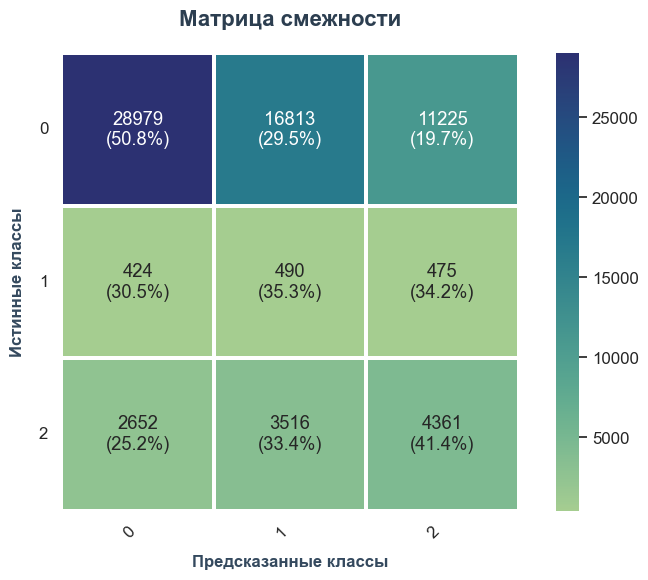

In [52]:
print("Logistic Regression")
print("sklearn metrics")
print("----------------------------")
print(f"f1_score: {f1_score(y_test, my_preds, average = "weighted")}")
print(f"Accuracy: {accuracy_score(y_test, my_preds)}")
print(f"Precision: {precision_score(y_test, my_preds, average = "weighted")}")
print(f"Recall: {recall_score(y_test, my_preds, average = "weighted")}")
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, my_preds), display_labels=np.unique(y_test))
disp.plot(cmap='viridis')
plt.show()

roc_auc = roc_auc_score(y_test, best_pred_logreg_proba, average="weighted", multi_class="ovr")
print(f"Roc-auc: {roc_auc}")

man_myKNN_prec, man_myKNN_rec, man_myKNN_f1, man_myKNN_acc = manual_metrics(y_test, my_preds)

print("\nmanual metrics")
print("----------------------------")
print(f"f1_score: {man_logReg_f1}")
print(f"Accuracy: {man_logReg_acc}")
print(f"Precision: {man_logReg_prec}")
print(f"Recall: {man_logReg_rec}")

plot_beautiful_confusion_matrix(y_test, my_preds)


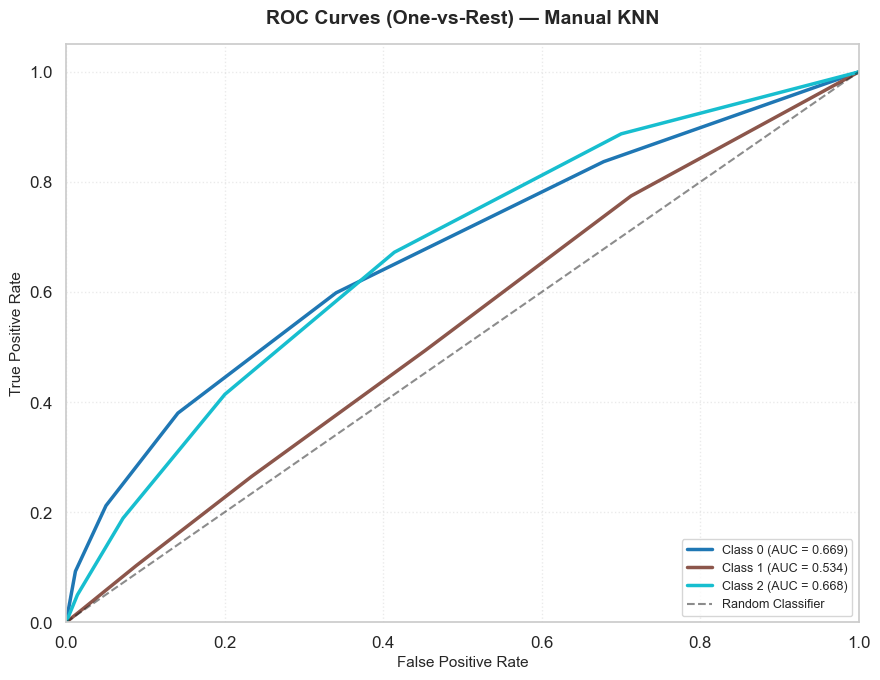

Weighted ROC-AUC: 0.6660


In [68]:
def get_manual_proba(X_train, y_train, X_query, k, classes):
    proba = np.zeros((len(X_query), len(classes)))
    for idx, x in enumerate(X_query):
        dists = np.sqrt(np.sum((X_train - x)**2, axis=1))
        k_idx = np.argpartition(dists, k)[:k]
        k_labels = y_train[k_idx]
        for i, cls in enumerate(classes):
            proba[idx, i] = np.sum(k_labels == cls) / k
    return proba

classes = np.unique(y_test)
my_knn_proba = get_manual_proba(
    np.asarray(X_train_res), np.asarray(y_train_res), 
    np.asarray(X_test), k=5, classes=classes
)

plt.figure(figsize=(9, 7), dpi=100)
colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))

for i, cls in enumerate(classes):
    y_binary = (y_test == cls).astype(int)
    y_score = my_knn_proba[:, i]
    
    fpr, tpr, _ = roc_curve(y_binary, y_score)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color=colors[i], linewidth=2.5,
             label=f'Class {cls} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curves (One-vs-Rest) — Manual KNN', 
          fontsize=14, weight='bold', pad=15)
plt.legend(loc='lower right', fontsize=9, frameon=True)
plt.grid(True, linestyle=':', alpha=0.4)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

weighted_auc = roc_auc_score(y_test, my_knn_proba, 
                             average='weighted', multi_class='ovr')
print(f"Weighted ROC-AUC: {weighted_auc:.4f}")